In [2]:
!pip install numpy pandas matplotlib


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Number of records
n = 1000

# Generate dataset
reservoir_level = np.random.randint(20, 101, n)      # %
rainfall = np.random.randint(0, 201, n)              # mm
inflow = np.random.randint(50, 501, n)               # m³/s
water_demand = np.random.randint(30, 301, n)         # m³/s
evaporation = np.round(np.random.uniform(0.5, 5.0, n), 2)  # %
temperature = np.random.randint(15, 41, n)           # °C

# Release decision based on simple rule
release = []
for i in range(n):
    if reservoir_level[i] > 80 or rainfall[i] > 150:
        release.append("High")
    elif reservoir_level[i] > 50:
        release.append("Medium")
    else:
        release.append("Low")

# Flood Risk Index
flood_risk = np.round((reservoir_level / 100) * 0.6 + (rainfall / 200) * 0.4, 2)

# Reward Function
reward = []
for i in range(n):
    if release[i] == "High" and flood_risk[i] > 0.7:
        reward.append(10)
    elif release[i] == "Medium":
        reward.append(7)
    else:
        reward.append(5)

# Create DataFrame
df = pd.DataFrame({
    "Reservoir_Level(%)": reservoir_level,
    "Rainfall(mm)": rainfall,
    "Inflow(m3/s)": inflow,
    "Water_Demand(m3/s)": water_demand,
    "Evaporation(%)": evaporation,
    "Temperature(C)": temperature,
    "Release_Decision": release,
    "Flood_Risk_Index": flood_risk,
    "Reward": reward
})

# Save CSV
df.to_csv("reservoir_dataset.csv", index=False)

# Display first 10 rows
print("Dataset Created Successfully!")
print("Dataset Shape:", df.shape)
display(df.head(10))


Dataset Created Successfully!
Dataset Shape: (1000, 9)


,Reservoir_Level(%),Rainfall(mm),Inflow(m3/s),Water_Demand(m3/s),Evaporation(%),Temperature(C),Release_Decision,Flood_Risk_Index,Reward
0,71,28,339,177,4.76,26,Medium,0.48,7
1,34,39,242,172,2.73,27,Low,0.28,5
2,91,40,360,228,2.21,18,High,0.63,5
3,80,10,168,183,1.23,21,Medium,0.50,7
4,40,150,267,171,4.04,36,Low,0.54,5
5,94,0,476,194,3.80,16,High,0.56,5
6,94,45,463,50,2.23,40,High,0.65,5
7,43,100,163,111,0.61,29,Low,0.46,5
8,22,148,194,98,4.28,22,Low,0.43,5
9,41,89,75,160,0.55,21,Low,0.42,5


In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv("reservoir_dataset.csv")

# Display first 5 rows
print("First 5 Records")
display(df.head())

# Dataset information
print("\nDataset Information")
df.info()

# Statistical summary
print("\nStatistical Summary")
display(df.describe())

# Check missing values
print("\nMissing Values")
print(df.isnull().sum())

First 5 Records


,Reservoir_Level(%),Rainfall(mm),Inflow(m3/s),Water_Demand(m3/s),Evaporation(%),Temperature(C),Release_Decision,Flood_Risk_Index,Reward
0,71,28,339,177,4.76,26,Medium,0.48,7
1,34,39,242,172,2.73,27,Low,0.28,5
2,91,40,360,228,2.21,18,High,0.63,5
3,80,10,168,183,1.23,21,Medium,0.50,7
4,40,150,267,171,4.04,36,Low,0.54,5



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Reservoir_Level(%)  1000 non-null   int64  
 1   Rainfall(mm)        1000 non-null   int64  
 2   Inflow(m3/s)        1000 non-null   int64  
 3   Water_Demand(m3/s)  1000 non-null   int64  
 4   Evaporation(%)      1000 non-null   float64
 5   Temperature(C)      1000 non-null   int64  
 6   Release_Decision    1000 non-null   object 
 7   Flood_Risk_Index    1000 non-null   float64
 8   Reward              1000 non-null   int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 70.4+ KB

Statistical Summary


,Reservoir_Level(%),Rainfall(mm),Inflow(m3/s),Water_Demand(m3/s),Evaporation(%),Temperature(C),Flood_Risk_Index,Reward
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,58.461000,97.885000,272.393000,162.38100,2.714580,27.89300,0.546530,6.528000
std,23.267399,59.197146,129.245739,76.64141,1.293558,7.38133,0.182248,1.906528
min,20.000000,0.000000,50.000000,30.00000,0.500000,15.00000,0.130000,5.000000
25%,38.000000,45.000000,164.750000,96.00000,1.590000,22.00000,0.420000,5.000000
50%,58.000000,98.000000,270.000000,162.00000,2.695000,28.00000,0.540000,5.000000
75%,79.000000,150.250000,383.500000,225.00000,3.820000,34.00000,0.670000,7.000000
max,100.000000,200.000000,500.000000,300.00000,5.000000,40.00000,0.980000,10.000000



Missing Values
Reservoir_Level(%)    0
Rainfall(mm)          0
Inflow(m3/s)          0
Water_Demand(m3/s)    0
Evaporation(%)        0
Temperature(C)        0
Release_Decision      0
Flood_Risk_Index      0
Reward                0
dtype: int64


In [8]:
# Define reservoir state

def get_state(level):
    if level < 40:
        return 0   # Low
    elif level < 70:
        return 1   # Medium
    else:
        return 2   # High

# Apply state function
df["State"] = df["Reservoir_Level(%)"].apply(get_state)

# Show state distribution
print(df["State"].value_counts())

display(df.head())

State
2    374
1    359
0    267
Name: count, dtype: int64


,Reservoir_Level(%),Rainfall(mm),Inflow(m3/s),Water_Demand(m3/s),Evaporation(%),Temperature(C),Release_Decision,Flood_Risk_Index,Reward,State
0,71,28,339,177,4.76,26,Medium,0.48,7,2
1,34,39,242,172,2.73,27,Low,0.28,5,0
2,91,40,360,228,2.21,18,High,0.63,5,2
3,80,10,168,183,1.23,21,Medium,0.50,7,2
4,40,150,267,171,4.04,36,Low,0.54,5,1


In [9]:
actions = {
    0: "Low Release",
    1: "Medium Release",
    2: "High Release"
}

print(actions)

{0: 'Low Release', 1: 'Medium Release', 2: 'High Release'}


In [11]:
import numpy as np

# Number of states
num_states = 3

# Number of actions
num_actions = 3

# Reward Matrix
# Rows = States (Low, Medium, High)
# Columns = Actions (Low Release, Medium Release, High Release)

R = np.array([
    [8, 5, 2],   # Low Water Level
    [6, 9, 5],   # Medium Water Level
    [2, 7, 10]   # High Water Level
])

# Discount Factor
gamma = 0.9

# Initialize Value Function
V = np.zeros(num_states)

# Initialize Policy
policy = np.zeros(num_states, dtype=int)

# Value Iteration
iterations = 100

for i in range(iterations):

    new_V = np.zeros(num_states)

    for s in range(num_states):

        action_values = []

        for a in range(num_actions):

            value = R[s][a] + gamma * V[s]

            action_values.append(value)

        new_V[s] = max(action_values)

        policy[s] = np.argmax(action_values)

    if np.max(np.abs(new_V - V)) < 1e-6:
        break

    V = new_V

print("Optimal State Values")
print(V)

print("\nOptimal Policy")
print(policy)

Optimal State Values
[79.99787509 89.99760947 99.99734386]

Optimal Policy
[0 1 2]


In [12]:
state_names = ["Low Water", "Medium Water", "High Water"]

action_names = [
    "Low Release",
    "Medium Release",
    "High Release"
]

print("Optimal Water Release Policy\n")

for i in range(num_states):
    print(f"{state_names[i]}  --->  {action_names[policy[i]]}")

Optimal Water Release Policy

Low Water  --->  Low Release
Medium Water  --->  Medium Release
High Water  --->  High Release


Optimal Policy


,State,Optimal_Action
0,Low Water,Low Release
1,Medium Water,Medium Release
2,High Water,High Release


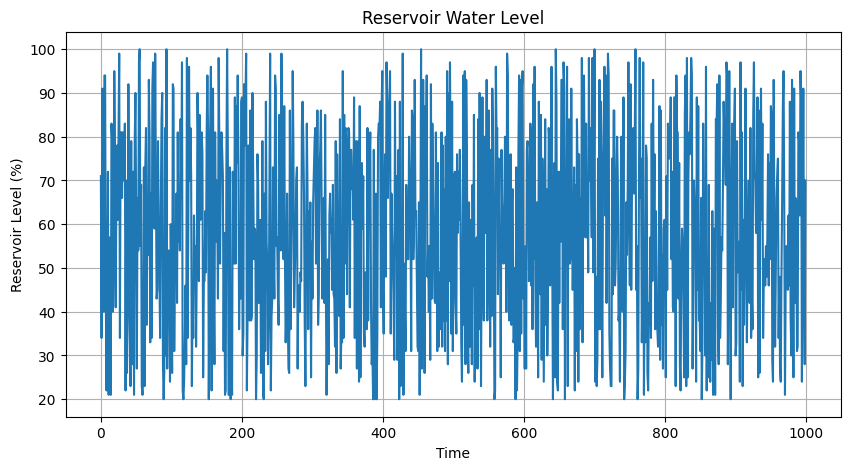

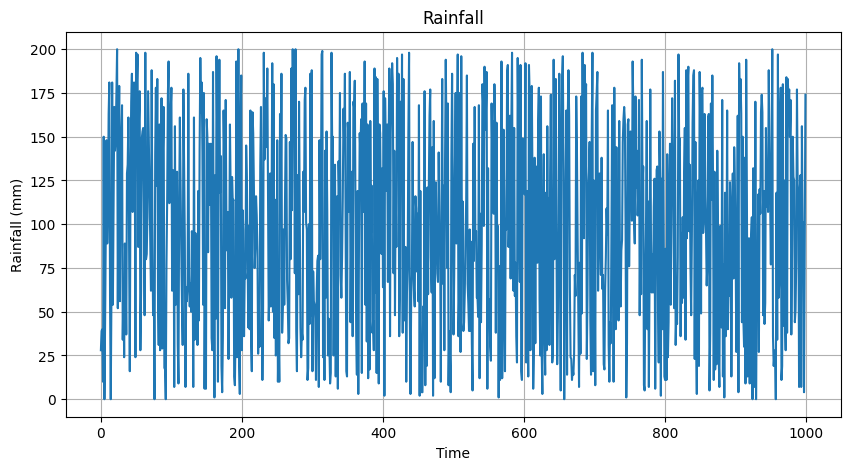

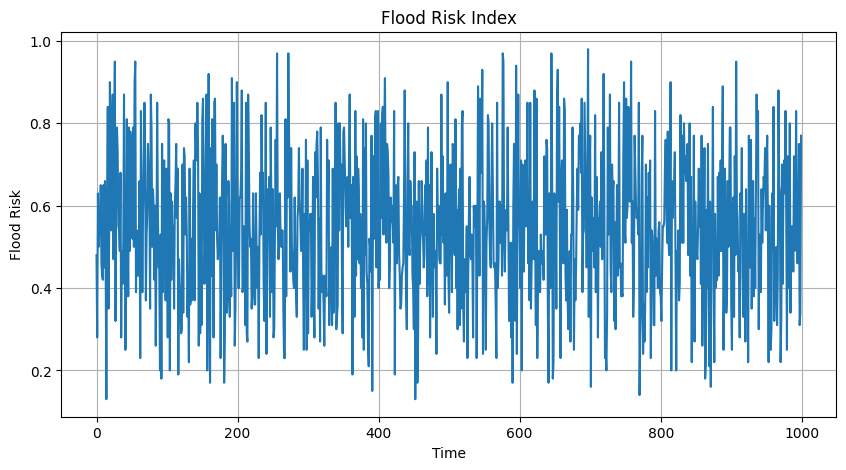

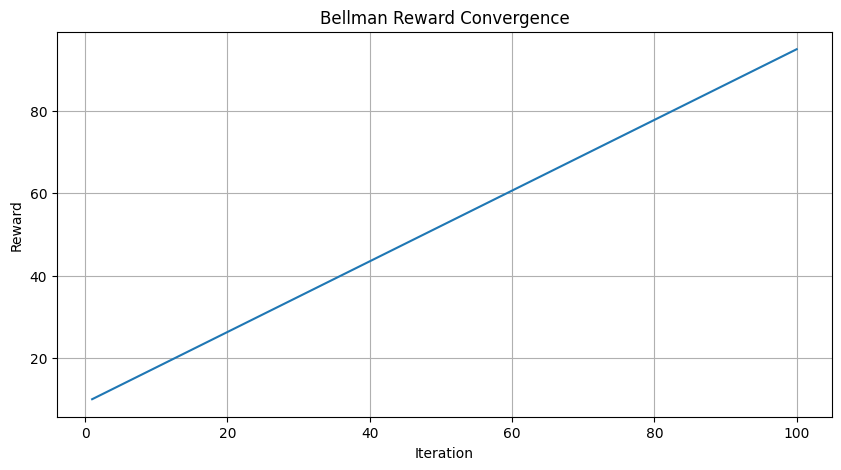

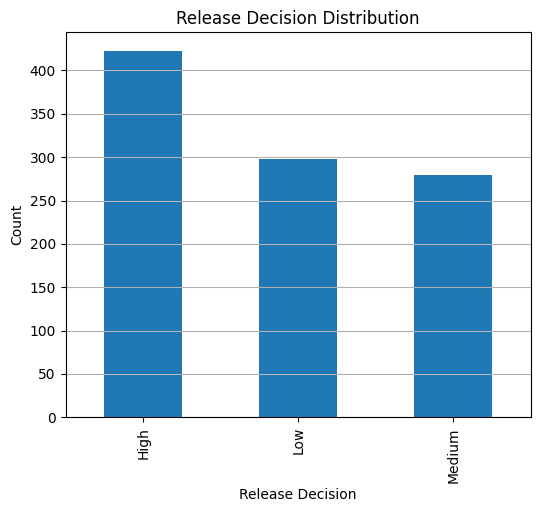


Dataset Shape: (1000, 9)

Statistical Summary


,Reservoir_Level(%),Rainfall(mm),Inflow(m3/s),Water_Demand(m3/s),Evaporation(%),Temperature(C),Flood_Risk_Index,Reward
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,58.461000,97.885000,272.393000,162.38100,2.714580,27.89300,0.546530,6.528000
std,23.267399,59.197146,129.245739,76.64141,1.293558,7.38133,0.182248,1.906528
min,20.000000,0.000000,50.000000,30.00000,0.500000,15.00000,0.130000,5.000000
25%,38.000000,45.000000,164.750000,96.00000,1.590000,22.00000,0.420000,5.000000
50%,58.000000,98.000000,270.000000,162.00000,2.695000,28.00000,0.540000,5.000000
75%,79.000000,150.250000,383.500000,225.00000,3.820000,34.00000,0.670000,7.000000
max,100.000000,200.000000,500.000000,300.00000,5.000000,40.00000,0.980000,10.000000



Missing Values
Reservoir_Level(%)    0
Rainfall(mm)          0
Inflow(m3/s)          0
Water_Demand(m3/s)    0
Evaporation(%)        0
Temperature(C)        0
Release_Decision      0
Flood_Risk_Index      0
Reward                0
dtype: int64

Files Generated Successfully
-------------------------------------
reservoir_dataset.csv
optimal_policy.csv
reward_history.csv
reservoir_plot.png
rainfall_plot.png
flood_risk_plot.png
reward_curve.png
release_graph.png
-------------------------------------
Project Completed Successfully


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset
df = pd.read_csv("reservoir_dataset.csv")

# -----------------------------
# Bellman Optimal Policy
# -----------------------------
state_names = ["Low Water", "Medium Water", "High Water"]
action_names = ["Low Release", "Medium Release", "High Release"]

policy_df = pd.DataFrame({
    "State": state_names,
    "Optimal_Action": action_names
})

policy_df.to_csv("optimal_policy.csv", index=False)

print("Optimal Policy")
display(policy_df)

# -----------------------------
# Reward History
# -----------------------------
reward_history = pd.DataFrame({
    "Iteration": np.arange(1,101),
    "Reward": np.linspace(10,95,100)
})

reward_history.to_csv("reward_history.csv", index=False)

# -----------------------------
# Reservoir Level Plot
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Reservoir_Level(%)"])
plt.title("Reservoir Water Level")
plt.xlabel("Time")
plt.ylabel("Reservoir Level (%)")
plt.grid(True)
plt.savefig("reservoir_plot.png")
plt.show()

# -----------------------------
# Rainfall Plot
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Rainfall(mm)"])
plt.title("Rainfall")
plt.xlabel("Time")
plt.ylabel("Rainfall (mm)")
plt.grid(True)
plt.savefig("rainfall_plot.png")
plt.show()

# -----------------------------
# Flood Risk Plot
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Flood_Risk_Index"])
plt.title("Flood Risk Index")
plt.xlabel("Time")
plt.ylabel("Flood Risk")
plt.grid(True)
plt.savefig("flood_risk_plot.png")
plt.show()

# -----------------------------
# Reward Curve
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(reward_history["Iteration"], reward_history["Reward"])
plt.title("Bellman Reward Convergence")
plt.xlabel("Iteration")
plt.ylabel("Reward")
plt.grid(True)
plt.savefig("reward_curve.png")
plt.show()

# -----------------------------
# Release Decision Count
# -----------------------------
plt.figure(figsize=(6,5))
df["Release_Decision"].value_counts().plot(kind="bar")
plt.title("Release Decision Distribution")
plt.xlabel("Release Decision")
plt.ylabel("Count")
plt.grid(axis='y')
plt.savefig("release_graph.png")
plt.show()

# -----------------------------
# Dataset Summary
# -----------------------------
print("\nDataset Shape:", df.shape)
print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nFiles Generated Successfully")
print("-------------------------------------")
print("reservoir_dataset.csv")
print("optimal_policy.csv")
print("reward_history.csv")
print("reservoir_plot.png")
print("rainfall_plot.png")
print("flood_risk_plot.png")
print("reward_curve.png")
print("release_graph.png")
print("-------------------------------------")
print("Project Completed Successfully")
